252
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 268.8 (χ²/ndof = 1.1)      │              Nfcn = 228              │
│ EDM = 1.75e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──

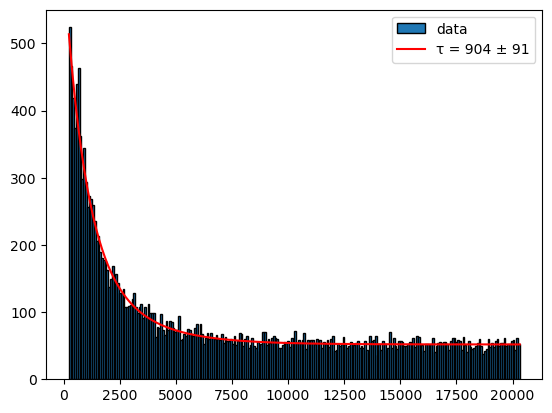

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
import raw
from importlib import reload
reload(raw)
from raw import raw_data


lines = np.linspace(0, 100, 30000)

data = np.array([int(h, 16)*80 for h in raw_data.split()])

counts, bins = np.histogram(data, bins=len(set(data)))
# There are 3 

print(len(set(data)))
centers = (bins[:-1] + bins[1:]) / 2
errors = np.sqrt(np.maximum(counts, 1))   

def model(x, N, M, tau, C):
    return (N*np.exp(-x / tau) + M* (np.exp(-((1/2.5)*x) / tau) ) ) + C

m = Minuit(LeastSquares(centers[1:-1], counts[1:-1], errors[1:-1], model), N=200, M = 200, tau=2000, C=5)
m.migrad()
m.hesse()
print(m)

plt.hist(data, bins=bins, edgecolor='black', label='data')
xs = np.linspace(bins[0], bins[-1], 300)
plt.plot(xs, model(xs, *m.values), 'r-', label=f"τ = {m.values['tau']:.0f} ± {m.errors['tau']:.0f}")
plt.legend()
plt.show()

[  560  5760  1120   560  1360  1600  6400   320   240 16720]
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 69.28 (χ²/ndof = 1.5)      │              Nfcn = 238              │
│ EDM = 3.14e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬──

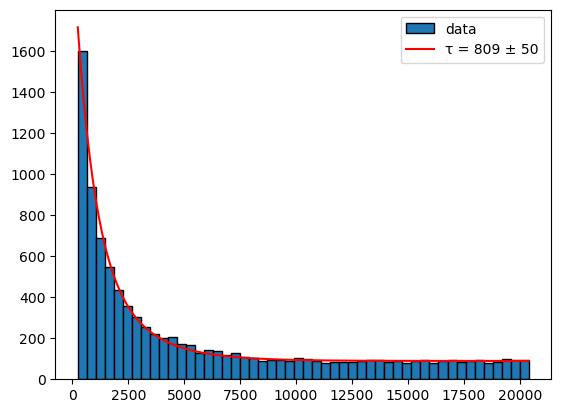

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
import raw
from importlib import reload
reload(raw)
from raw import raw_data_other


lines = np.linspace(0, 100, 25000)

data = np.array([int(h, 16)*80 for h in raw_data_other.split()])

print(data[0:10])

counts, bins = np.histogram(data, bins=50)
centers = (bins[:-1] + bins[1:]) / 2
errors = np.sqrt(np.maximum(counts, 1))   

def model(x, N, M, tau, C):
    return (N*np.exp(-x / tau) + M* (np.exp(-((1/2.5)*x) / tau) ) ) + C

m = Minuit(LeastSquares(centers, counts, errors, model), N=200, M = 200, tau=2000, C=5)
m.migrad()
m.hesse()
print(m)

plt.hist(data, bins=bins, edgecolor='black', label='data')
xs = np.linspace(bins[0], bins[-1], 300)
plt.plot(xs, model(xs, *m.values), 'r-', label=f"τ = {m.values['tau']:.0f} ± {m.errors['tau']:.0f}")
plt.legend()
plt.show()